In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("C:/Users/PRITAM/Downloads/air_quality_health_impact_data.csv")

# 1. How does AQI vary with different levels of PM2.5 and PM10?

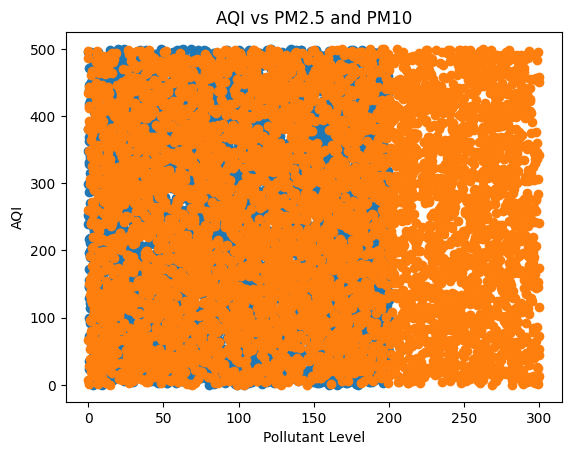

In [20]:
#plt.figure(figsize=(10, 5))
plt.scatter(df["PM2_5"], df["AQI"], label="PM2.5 vs AQI")
plt.scatter(df["PM10"], df["AQI"], label="PM10 vs AQI")
plt.xlabel("Pollutant Level")
plt.ylabel("AQI")
#plt.legend()
plt.title("AQI vs PM2.5 and PM10")
plt.show()

# 2. What is the correlation between different pollutants and AQI?

<Figure size 800x600 with 0 Axes>

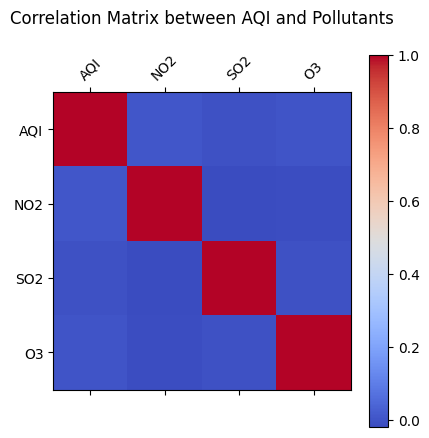

          AQI       NO2       SO2        O3
AQI  1.000000  0.007836 -0.006644  0.002339
NO2  0.007836  1.000000 -0.019979 -0.014910
SO2 -0.006644 -0.019979  1.000000 -0.004319
O3   0.002339 -0.014910 -0.004319  1.000000


In [14]:
# Calculate correlation matrix for AQI and pollutants
correlation_matrix = data[['AQI', 'NO2', 'SO2', 'O3']].corr()

# Plotting the correlation matrix using plt.matshow without specifying fignum
plt.figure(figsize=(8, 6))
plt.matshow(correlation_matrix, cmap='coolwarm')
plt.colorbar()
plt.title('Correlation Matrix between AQI and Pollutants', pad=20)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.show()

print(correlation_matrix)

# 3. How does temperature influence AQI and pollutant levels?

C:\Users\PRITAM\AppData\Local\Temp\ipykernel_8564\2555821875.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_avg = data.groupby('Temperature_bin').mean()[['AQI', 'PM2_5']].reset_index()


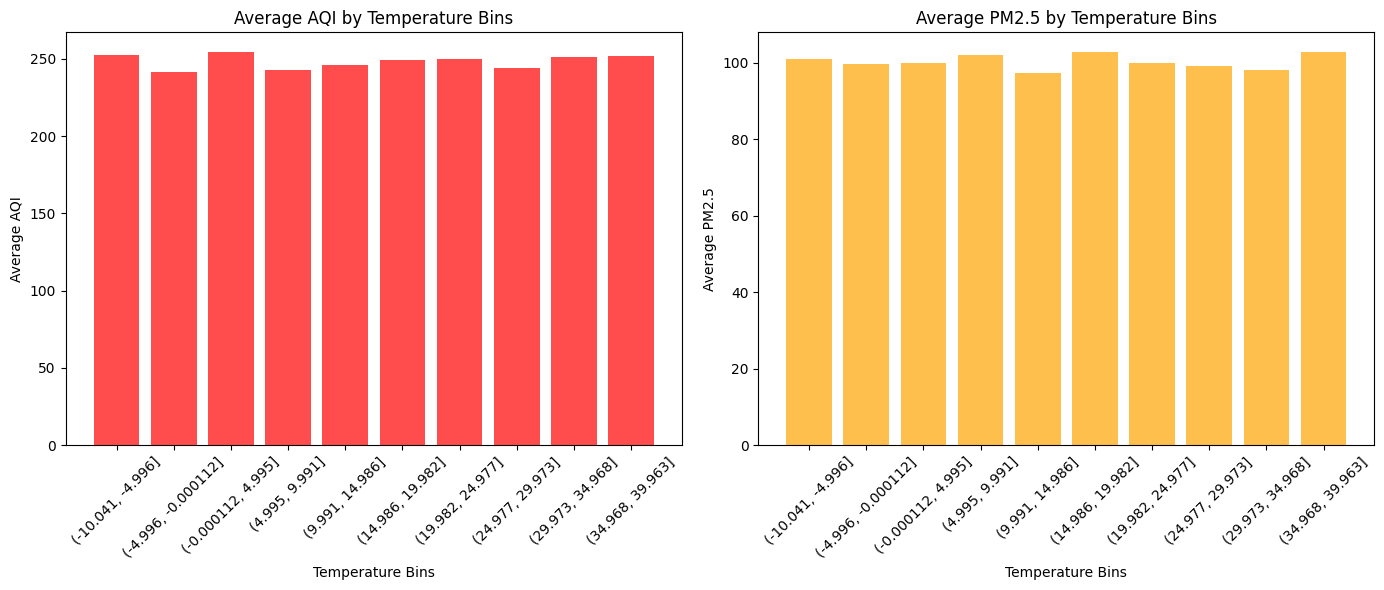

In [16]:
# Bin temperature values into 10 equal-width bins
data['Temperature_bin'] = pd.cut(data['Temperature'], bins=10)

# Group by the temperature bins and calculate average AQI and PM2.5 for each bin
temp_bin_avg = data.groupby('Temperature_bin').mean()[['AQI', 'PM2_5']].reset_index()

# Convert the temperature bin intervals to string for clear labeling
temp_bin_avg['Temperature_bin_str'] = temp_bin_avg['Temperature_bin'].astype(str)

plt.figure(figsize=(14, 6))

# Bar chart for average AQI by Temperature bins
plt.subplot(1, 2, 1)
plt.bar(temp_bin_avg['Temperature_bin_str'], temp_bin_avg['AQI'], color='red', alpha=0.7)
plt.title('Average AQI by Temperature Bins')
plt.xlabel('Temperature Bins')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)

# Bar chart for average PM2.5 by Temperature bins
plt.subplot(1, 2, 2)
plt.bar(temp_bin_avg['Temperature_bin_str'], temp_bin_avg['PM2_5'], color='orange', alpha=0.7)
plt.title('Average PM2.5 by Temperature Bins')
plt.xlabel('Temperature Bins')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Does humidity have an impact on air pollution levels?

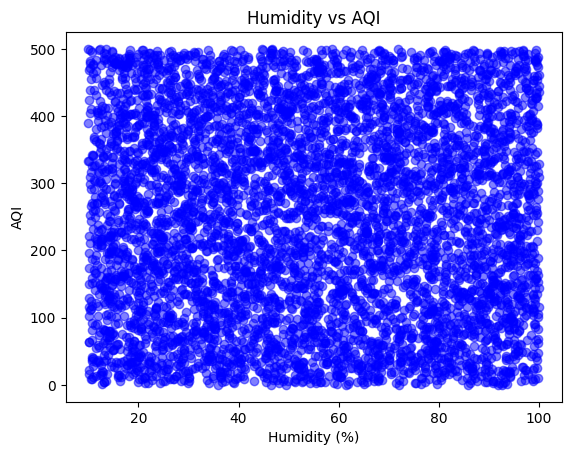

In [9]:
plt.scatter(df["Humidity"], df["AQI"], alpha=0.5, color='b')
plt.xlabel("Humidity (%)")
plt.ylabel("AQI")
plt.title("Humidity vs AQI")
plt.show()

# 5. What is the relationship between wind speed and pollutant dispersion?

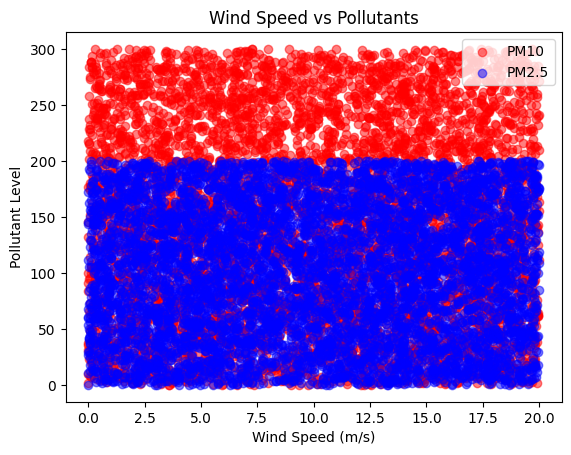

In [10]:
plt.scatter(df["WindSpeed"], df["PM10"], alpha=0.5, label="PM10", color='r')
plt.scatter(df["WindSpeed"], df["PM2_5"], alpha=0.5, label="PM2.5", color='b')
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Pollutant Level")
plt.legend()
plt.title("Wind Speed vs Pollutants")
plt.show()